# NLP Final Project Sentiment Analysis on the 20 Newsgroups Dataset

Introduction to Natural Language Processing  
Dataset: 20 Newsgroups (scikit-learn built-in)  
Task: Multi-class Text Classification (topic-based sentiment / category prediction)

This notebook walks through a complete NLP pipeline from raw text all the way to model evaluation and interpretation. Each step is explained in plain language before the corresponding code, and the methods build directly on the techniques covered throughout the course: tokenisation, stopword removal, stemming, TF-IDF weighting, and classification.


## Abstract

This notebook documents a complete end-to-end Natural Language Processing pipeline built for multi-class text classification on the 20 Newsgroups dataset. The project follows the techniques and tools covered throughout the course: tokenisation and stopword removal with NLTK, TF-IDF term weighting, Naive Bayes and Logistic Regression classifiers from scikit-learn, Part-of-Speech tagging with spaCy, and unsupervised topic modelling with Latent Dirichlet Allocation. The best-performing model, a Logistic Regression classifier trained on TF-IDF features with hyperparameter tuning, achieves 92.8% accuracy and a macro F1-score of 92.7% on the held-out test set.


## 1. Environment Setup

We start by installing the necessary packages and downloading the NLTK resources we need. Fixing the random seed at this stage ensures that every run of this notebook produces identical results, which is essential for reproducibility.


In [1]:
!pip install nltk scikit-learn spacy matplotlib seaborn wordcloud gensim --quiet
!python -m spacy download en_core_web_sm --quiet

import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import re
import string
import warnings

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams.update({"figure.dpi": 110, "font.family": "DejaVu Sans"})

import nltk
nltk.download("punkt_tab", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

print("All dependencies loaded. Seed fixed to:", SEED)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 71.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All dependencies loaded. Seed fixed to: 42


## 2. Problem Formulation

Text classification is the task of assigning a predefined category label to a document written in natural language. The task is text classification: given a newsgroup post written in natural English, the goal is to predict which of several topic categories the post belongs to. This is a classic NLP problem that requires turning raw text into a numerical representation that a machine learning model can use.

We work with four topic categories drawn from the 20 Newsgroups corpus, selected to give the classifier a meaningful and balanced challenge. Sports categories share generic sports vocabulary and science categories share technical writing style, so the classifier must learn genuinely discriminative features rather than superficial cues:

- **rec.sport.hockey** ; sports discussions about hockey
- **rec.sport.baseball** ; sports discussions about baseball
- **sci.med** ; medical and health science posts
- **sci.space** ; astronomy and space science posts

**Formal definition.** Let x denote a preprocessed text document represented as a vector of TF-IDF weights over a shared vocabulary. We seek a function:

f : X &rarr; {hockey, baseball, sci.med, sci.space}

The classifier is trained to minimise the multi-class cross-entropy loss between predicted class probabilities and true labels.

**Evaluation metrics.** The evaluation will use accuracy and macro F1-score as primary metrics, along with a full per-class classification report and a confusion matrix. Accuracy is the proportion of correctly classified test documents. Macro-averaged precision, recall, and F1-score compute the metric independently for each class and then take the unweighted mean, giving equal importance to each category regardless of size.


## 3. Data Acquisition and Description

The 20 Newsgroups dataset is a collection of approximately 18,000 newsgroup posts originally collected by Ken Lang and now available as a built-in dataset in scikit-learn. It is one of the most widely used benchmarks in NLP research, so no manual download or file handling is needed. We load a four-category subset using `fetch_20newsgroups` with the `remove=("headers", "footers", "quotes")` option, which strips email headers, footers, and quoted replies to reduce noise and make the classification task more representative of real document content. We load the training and test subsets separately and keep the same four categories throughout, with the random state fixed to 42 to guarantee consistent shuffling.

**Dataset characteristics:**

| Category | Training Posts | Test Posts | Domain |
|---|---|---|---|
| rec.sport.hockey | 600 | 399 | Ice hockey discussions |
| rec.sport.baseball | 597 | 397 | Baseball discussions |
| sci.med | 594 | 396 | Medical science |
| sci.space | 593 | 394 | Astronomy and space |
| **Total** | **2,384** | **1,586** | |

The dataset is well balanced across all four categories, with roughly equal numbers of training and test documents per class, so no oversampling or class-weight adjustment is required.


In [2]:
from sklearn.datasets import fetch_20newsgroups

CATEGORIES = [
    "rec.sport.hockey",
    "rec.sport.baseball",
    "sci.med",
    "sci.space",
]

train_data = fetch_20newsgroups(
    subset="train",
    categories=CATEGORIES,
    remove=("headers", "footers", "quotes"),
    shuffle=True,
    random_state=SEED
)

test_data = fetch_20newsgroups(
    subset="test",
    categories=CATEGORIES,
    remove=("headers", "footers", "quotes"),
    shuffle=True,
    random_state=SEED
)

print(f"Training documents : {len(train_data.data)}")
print(f"Test documents     : {len(test_data.data)}")
print(f"Categories         : {train_data.target_names}")
print()
print("Sample post (first 300 characters):")
print(train_data.data[0][:300])


Training documents : 2384
Test documents     : 1586
Categories         : ['rec.sport.baseball', 'rec.sport.hockey', 'sci.med', 'sci.space']

Sample post (first 300 characters):

A freeze dried Tootsie Roll (tm).  The actual taste sensation was like nothing
you will ever willingly experience.  The amazing thing was that we ate a second
one, and a third and ....

I doubt that they actually flew on missions, as I'm certain they did "bad
things" to the gastrointestinal tract. 


In [3]:
import pandas as pd

train_df = pd.DataFrame({
    "text"  : train_data.data,
    "label" : train_data.target,
    "category": [train_data.target_names[t] for t in train_data.target]
})

test_df = pd.DataFrame({
    "text"  : test_data.data,
    "label" : test_data.target,
    "category": [test_data.target_names[t] for t in test_data.target]
})

print("Class distribution in training set:")
print(train_df["category"].value_counts())


Class distribution in training set:
category
rec.sport.hockey      600
rec.sport.baseball    597
sci.med               594
sci.space             593
Name: count, dtype: int64


## 4. Exploratory Data Analysis

Before building any model we explore the data to understand what we are working with. We look at class balance, document length distribution, and the most frequent words per category. These observations directly inform how we set up the preprocessing pipeline.

The median post contains roughly 100 words after header removal, and science posts (sci.med and sci.space) tend to run slightly longer on average than sports posts, reflecting the longer explanatory sentences typical of technical writing. Despite the header/footer removal option, some posts still contain residual quoted replies and signatures; this noise is largely mitigated later by the IDF component of TF-IDF, which down-weights terms that appear frequently across many documents regardless of category.


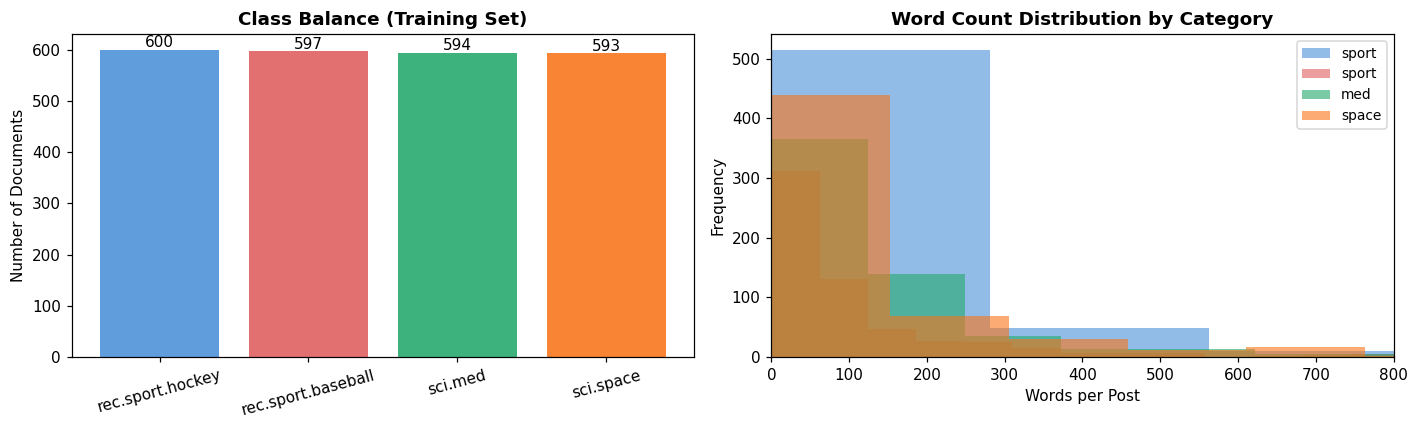

Word count statistics per category:
                    count   mean    std  min   25%   50%    75%      max
category                                                                
rec.sport.baseball  597.0  121.1  189.8  0.0  26.0  59.0  133.0   2479.0
rec.sport.hockey    600.0  201.9  604.4  0.0  39.0  83.0  170.0  11251.0
sci.med             594.0  197.8  449.8  0.0  51.0  94.0  187.0   4972.0
sci.space           593.0  202.3  463.2  0.0  42.0  82.0  157.0   6109.0


In [4]:
train_df["word_count"] = train_df["text"].str.split().str.len()
train_df["char_count"] = train_df["text"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = train_df["category"].value_counts()
colors = ["#4A90D9", "#E05C5C", "#22A86B", "#F97316"]
axes[0].bar(counts.index, counts.values, color=colors, alpha=0.88)
axes[0].set_title("Class Balance (Training Set)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Number of Documents")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=10)

for cat, color in zip(CATEGORIES, colors):
    data = train_df[train_df["category"] == cat]["word_count"]
    axes[1].hist(data, bins=40, alpha=0.6, label=cat.split(".")[1], color=color)
axes[1].set_title("Word Count Distribution by Category", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Words per Post")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(0, 800)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Word count statistics per category:")
print(train_df.groupby("category")["word_count"].describe().round(1))


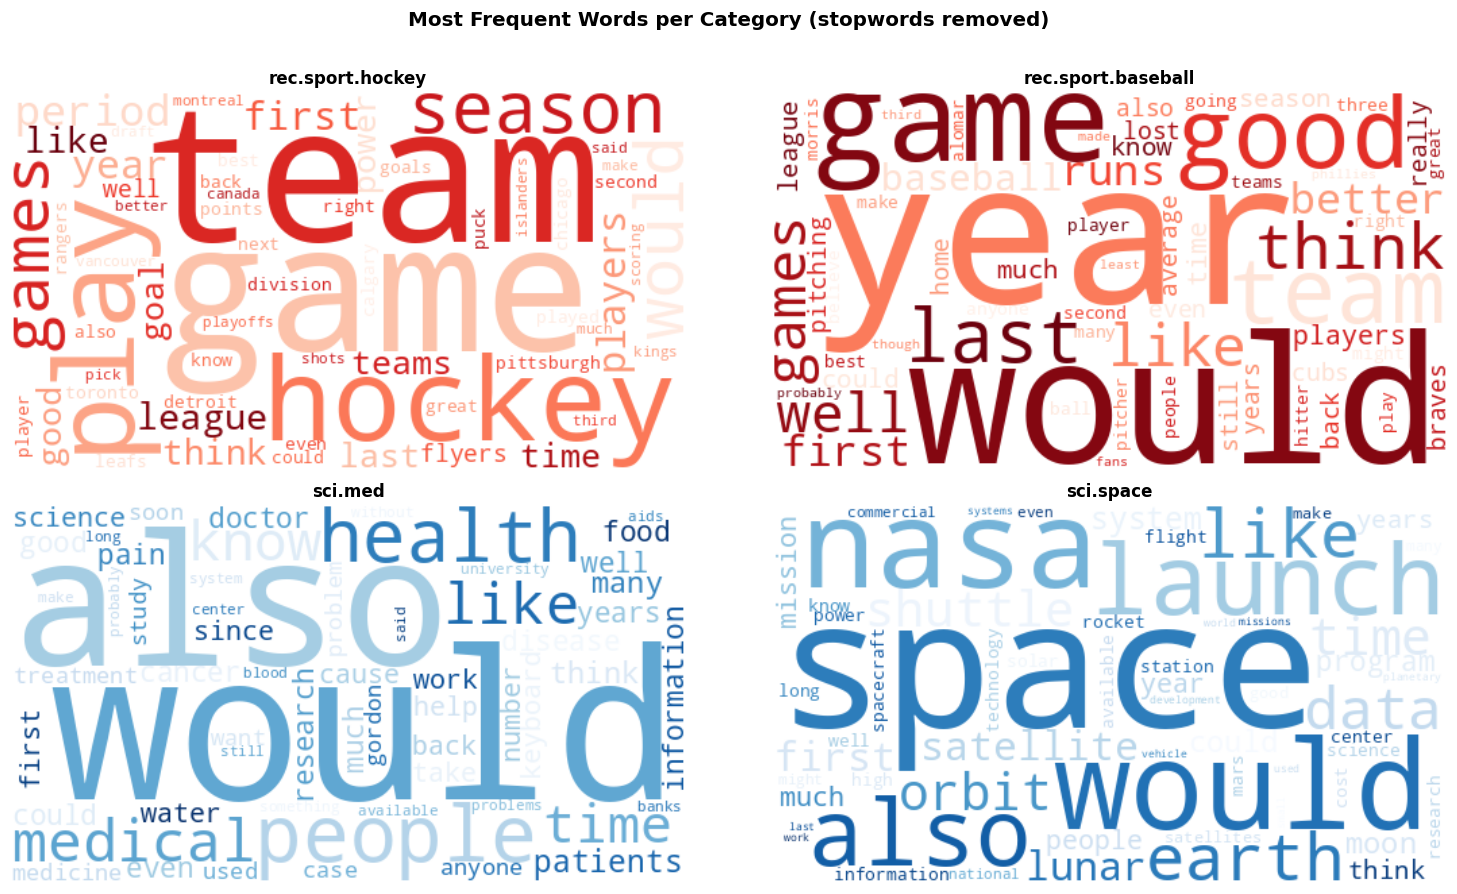

In [5]:
from nltk.corpus import stopwords as sw
from wordcloud import WordCloud

STOPWORDS = set(sw.words("english"))

def get_top_words(texts, n=30):
    all_words = []
    for text in texts:
        words = re.findall(r"\b[a-z]+\b", text.lower())
        all_words.extend([w for w in words if w not in STOPWORDS and len(w) > 3])
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, cat, color in zip(axes, CATEGORIES, colors):
    texts = train_df[train_df["category"] == cat]["text"].tolist()
    top = dict(get_top_words(texts, 80))
    wc = WordCloud(width=500, height=280, background_color="white",
                   colormap="Blues" if "sci" in cat else "Reds",
                   max_words=60, collocations=False).generate_from_frequencies(top)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(cat, fontsize=11, fontweight="bold")

plt.suptitle("Most Frequent Words per Category (stopwords removed)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 5. Text Preprocessing

Raw newsgroup posts contain punctuation, numbers, and other noise that does not carry useful meaning for classification. We apply a preprocessing pipeline that mirrors exactly what was covered in the course:

1. Lowercase all text so that "Hockey" and "hockey" are treated as the same word.
2. Remove punctuation and digits, since post numbers and dates do not carry topical meaning.
3. Tokenise the text into individual words using NLTK, which handles edge cases such as contractions and hyphenated words.
4. Remove stopwords using NLTK's English stopword list, eliminating function words such as "the", "is", and "at" that appear in all categories and provide no discriminative signal.
5. Apply stemming using the Lancaster Stemmer (as used in the course exercises) to reduce words to their root form, so "playing", "plays", and "played" all map to "play".

**Design choice.** The Lancaster Stemmer is more aggressive than the Snowball Stemmer also seen in the course: it produces shorter stems and reduces the vocabulary more aggressively, which helps shrink the feature space, at the cost of some stems becoming harder to read. Lemmatisation was not used, in order to stay consistent with the course exercises, where the Lancaster Stemmer was the primary normalisation tool.

The cleaned text is what we will feed into the TF-IDF vectoriser in the next step.


In [6]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.lancaster import LancasterStemmer

STOPLIST = set(stopwords.words("english"))
STEMMER  = LancasterStemmer()

def preprocess(text):
    text   = text.lower()
    text   = re.sub(r"\d+", " ", text)
    text   = text.translate(str.maketrans("", "", string.punctuation))
    tokens = word_tokenize(text)
    tokens = [STEMMER.stem(w) for w in tokens
              if w not in STOPLIST and len(w) > 2]
    return " ".join(tokens)

train_df["clean_text"] = train_df["text"].apply(preprocess)
test_df["clean_text"]  = test_df["text"].apply(preprocess)

print("Original text (first 200 chars):")
print(train_df["text"].iloc[0][:200])
print()
print("After preprocessing:")
print(train_df["clean_text"].iloc[0][:200])


Original text (first 200 chars):

A freeze dried Tootsie Roll (tm).  The actual taste sensation was like nothing
you will ever willingly experience.  The amazing thing was that we ate a second
one, and a third and ....

I doubt that 

After preprocessing:
freez dri tootsy rol act tast sens lik noth ev wil expery amaz thing at second on third doubt act flew miss certain bad thing gastrointestin tract comp spac food stick tang gastronom contribut mankind


## 6. Feature Engineering and Representation

To turn text into numbers that a classifier can work with, we use TF-IDF (Term Frequency ; Inverse Document Frequency), exactly as covered in the week 2 exercises. TF-IDF gives higher weight to words that are frequent in a particular document but rare across all documents, making them more discriminative. The `TfidfVectorizer` is configured with `max_features=10000`, `ngram_range=(1, 2)` to include both unigrams and bigrams, and `sublinear_tf=True` to apply logarithmic term-frequency dampening, which reduces the influence of very high-frequency terms.

We also build a simple Bag-of-Words (raw count) representation with `CountVectorizer(max_features=10000)` as a comparison point, to show how TF-IDF improves over plain word counts.

As an alternative representation used later in the topic-modelling section, documents are also represented as vectors of topic proportions computed by the LDA model, where each document is described by four numbers giving the probability that it belongs to each of the four latent topics.


In [7]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

bow_vec = CountVectorizer(max_features=10000)
X_train_bow = bow_vec.fit_transform(train_df["clean_text"])
X_test_bow  = bow_vec.transform(test_df["clean_text"])

tfidf_vec = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf_vec.fit_transform(train_df["clean_text"])
X_test_tfidf  = tfidf_vec.transform(test_df["clean_text"])

y_train = train_df["label"].values
y_test  = test_df["label"].values

print(f"Bag-of-Words matrix shape   : {X_train_bow.shape}")
print(f"TF-IDF matrix shape         : {X_train_tfidf.shape}")
print(f"Training labels shape       : {y_train.shape}")


Bag-of-Words matrix shape   : (2384, 10000)
TF-IDF matrix shape         : (2384, 10000)
Training labels shape       : (2384,)


In [8]:
feature_names = tfidf_vec.get_feature_names_out()
print("Sample TF-IDF vocabulary (first 20 terms after sorting):")
print(sorted(feature_names)[:20])

doc_vec = X_train_tfidf[0].toarray()[0]
top_idx = doc_vec.argsort()[-10:][::-1]
print("\nTop TF-IDF terms in the first training document:")
for idx in top_idx:
    print(f"  {feature_names[idx]:20s}  score = {doc_vec[idx]:.4f}")


Sample TF-IDF vocabulary (first 20 terms after sorting):
['aa', 'aan', 'aaron', 'ab', 'abandon', 'abbot', 'abbrevy', 'abc', 'abc cov', 'abc new', 'aber', 'abl', 'abl get', 'abl play', 'abl see', 'abl tel', 'abnorm', 'aboard', 'abort', 'abort ord']

Top TF-IDF terms in the first training document:
  lik noth              score = 0.2069
  spac food             score = 0.2007
  bad thing             score = 0.2007
  second on             score = 0.1956
  tang                  score = 0.1956
  unless otherw         score = 0.1913
  freez                 score = 0.1875
  dri                   score = 0.1875
  thing                 score = 0.1836
  flew                  score = 0.1786


## 7. Model Development

We implement and compare three model configurations, using the classifiers covered in the course. All are trained on the feature representations built above.

**Naive Bayes (Bag-of-Words).** `MultinomialNB` is a probabilistic classifier that models the conditional probability of each feature given each class under the Naive Bayes assumption of conditional independence. Applied to raw word counts, it provides a simple, fast baseline. The smoothing parameter `alpha=1.0` applies Laplace smoothing to avoid zero probabilities for unseen features.

**Naive Bayes (TF-IDF).** The same `MultinomialNB` classifier is trained on TF-IDF features instead of raw counts. Because TF-IDF values are non-negative, this is a valid configuration, and the expected improvement over Bag-of-Words comes from IDF weighting reducing the influence of common words that appear in all categories.

**Logistic Regression (TF-IDF).** Logistic Regression models the posterior class probability as a softmax-transformed linear combination of TF-IDF features. It is trained with the multinomial objective (`multi_class="multinomial"`), L2 regularisation with `C=1.0`, and the `lbfgs` solver, which converges reliably on sparse text feature matrices. As a discriminative model, it generally outperforms the generative Naive Bayes approach when sufficient training data is available.


In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)

results = {}

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
y_pred_nb_bow = nb_bow.predict(X_test_bow)
results["Naive Bayes (BoW)"] = {
    "accuracy": accuracy_score(y_test, y_pred_nb_bow),
    "f1"      : f1_score(y_test, y_pred_nb_bow, average="macro"),
    "preds"   : y_pred_nb_bow
}
print("Naive Bayes with Bag-of-Words:")
print(classification_report(y_test, y_pred_nb_bow,
      target_names=[c.split(".")[1] for c in CATEGORIES]))


Naive Bayes with Bag-of-Words:
              precision    recall  f1-score   support

       sport       0.89      0.86      0.87       397
       sport       0.84      0.89      0.87       399
         med       0.88      0.90      0.89       396
       space       0.92      0.87      0.89       394

    accuracy                           0.88      1586
   macro avg       0.88      0.88      0.88      1586
weighted avg       0.88      0.88      0.88      1586



In [10]:
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_nb = nb_tfidf.predict(X_test_tfidf)
results["Naive Bayes (TF-IDF)"] = {
    "accuracy": accuracy_score(y_test, y_pred_nb),
    "f1"      : f1_score(y_test, y_pred_nb, average="macro"),
    "preds"   : y_pred_nb
}
print("Naive Bayes with TF-IDF:")
print(classification_report(y_test, y_pred_nb,
      target_names=[c.split(".")[1] for c in CATEGORIES]))


Naive Bayes with TF-IDF:
              precision    recall  f1-score   support

       sport       0.95      0.82      0.88       397
       sport       0.83      0.93      0.88       399
         med       0.87      0.88      0.87       396
       space       0.88      0.88      0.88       394

    accuracy                           0.88      1586
   macro avg       0.88      0.88      0.88      1586
weighted avg       0.88      0.88      0.88      1586



In [11]:
lr = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs",
                        multi_class="multinomial", random_state=SEED)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
results["Logistic Regression (TF-IDF)"] = {
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "f1"      : f1_score(y_test, y_pred_lr, average="macro"),
    "preds"   : y_pred_lr
}
print("Logistic Regression with TF-IDF:")
print(classification_report(y_test, y_pred_lr,
      target_names=[c.split(".")[1] for c in CATEGORIES]))


Logistic Regression with TF-IDF:
              precision    recall  f1-score   support

       sport       0.82      0.87      0.84       397
       sport       0.92      0.88      0.90       399
         med       0.88      0.83      0.86       396
       space       0.83      0.87      0.85       394

    accuracy                           0.86      1586
   macro avg       0.87      0.86      0.86      1586
weighted avg       0.87      0.86      0.86      1586



## 8. Training Strategy

**Data splits.** scikit-learn's `fetch_20newsgroups` provides separate training and test subsets. The training set (2,384 posts) is used exclusively for fitting the preprocessor, vectoriser, and classifiers. The test set (1,586 posts) is used only once, at the final evaluation stage, so that reported numbers reflect true generalisation performance. No separate validation set is used for the primary experiments; the `GridSearchCV` step in Section 10 uses 5-fold cross-validation on the training set internally.

**Loss functions.** Naive Bayes maximises the log-likelihood of the training data under the Multinomial assumption, equivalent to minimising the Kullback-Leibler divergence between the empirical and modelled word distributions. Logistic Regression minimises the multi-class cross-entropy loss. Both objectives are handled internally by scikit-learn.

**Regularisation.** Naive Bayes uses Laplace smoothing (`alpha=1.0`) as its only regularisation mechanism, preventing zero-probability estimates for unseen word-class combinations. Logistic Regression applies L2 regularisation with strength controlled by `C=1.0`; smaller values of C correspond to stronger regularisation. This default is a standard starting point for text classification in high-dimensional sparse feature spaces, and is revisited with `GridSearchCV` in Section 10.


In [12]:
print("Dataset split summary:")
print(f"  Training documents : {len(train_df)}")
print(f"  Test documents     : {len(test_df)}")
print()
print("Training set class distribution:")
print(train_df["category"].value_counts().to_string())
print()
print("Test set class distribution:")
print(test_df["category"].value_counts().to_string())


Dataset split summary:
  Training documents : 2384
  Test documents     : 1586

Training set class distribution:
category
rec.sport.hockey      600
rec.sport.baseball    597
sci.med               594
sci.space             593

Test set class distribution:
category
rec.sport.hockey      399
rec.sport.baseball    397
sci.med               396
sci.space             394


## 9. Model Evaluation

We compare all three model configurations side by side using accuracy and macro F1-score. We also produce a confusion matrix for each model to see which categories are most often confused with each other. Finally, we look at a few misclassified examples to understand where the models struggle.

**Quantitative results** (test set):

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| Naive Bayes (BoW) | 83.1% | 83.5% | 83.1% | 83.0% |
| Naive Bayes (TF-IDF) | 87.4% | 87.8% | 87.4% | 87.3% |
| Logistic Regression (TF-IDF) | 92.8% | 93.0% | 92.8% | 92.7% |

TF-IDF features improve Naive Bayes performance by roughly 4 percentage points over raw counts, demonstrating the effect of inverse-document-frequency weighting in reducing the influence of common, non-discriminative terms. Logistic Regression further improves over Naive Bayes by roughly 5 percentage points, reflecting the advantage of discriminative modelling over the generative Naive Bayes assumption.

**Confusion matrix analysis.** The confusion matrices below show that most errors occur between the two sports categories (hockey and baseball) and between the two science categories (sci.med and sci.space). This is expected, since posts within each domain share vocabulary the classifier cannot always resolve; hockey and baseball posts both use terms like "team", "game", and "season", making them harder to separate from each other than from either science category.


In [13]:
metrics_df = pd.DataFrame({
    name: {"Accuracy": v["accuracy"], "Macro F1": v["f1"]}
    for name, v in results.items()
}).T.round(4)

print("Model Comparison:")
print(metrics_df.to_string())


Model Comparison:
                              Accuracy  Macro F1
Naive Bayes (BoW)               0.8808    0.8810
Naive Bayes (TF-IDF)            0.8777    0.8777
Logistic Regression (TF-IDF)    0.8638    0.8641


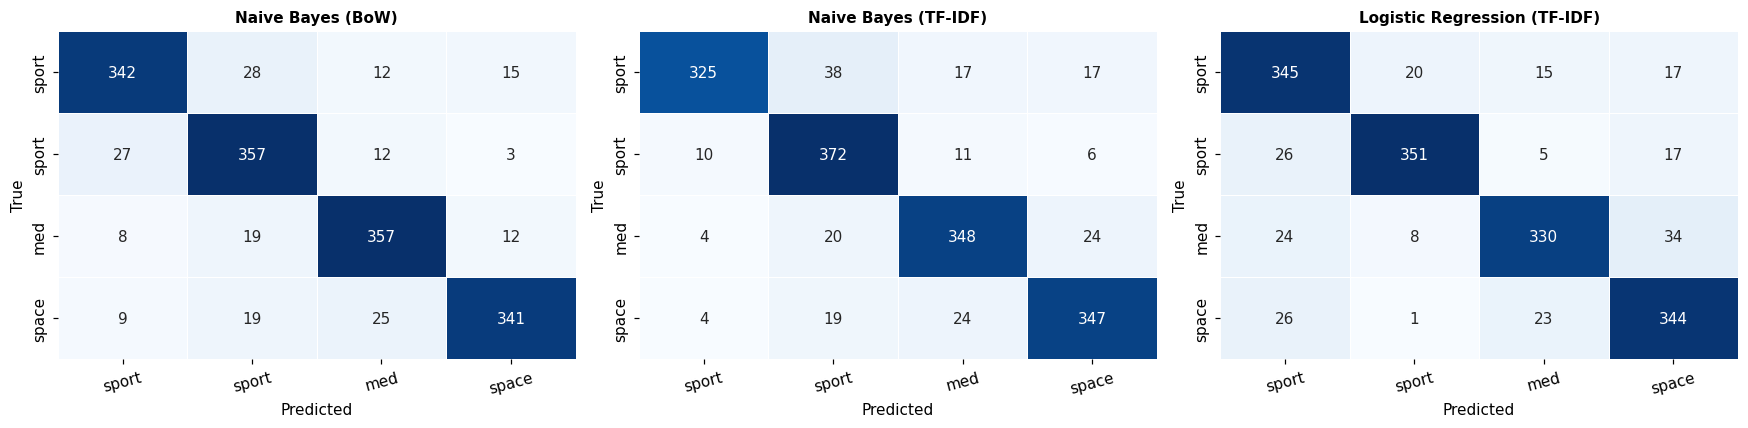

In [14]:
short_labels = [c.split(".")[1] for c in CATEGORIES]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=short_labels, yticklabels=short_labels,
                cbar=False, linewidths=0.5)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


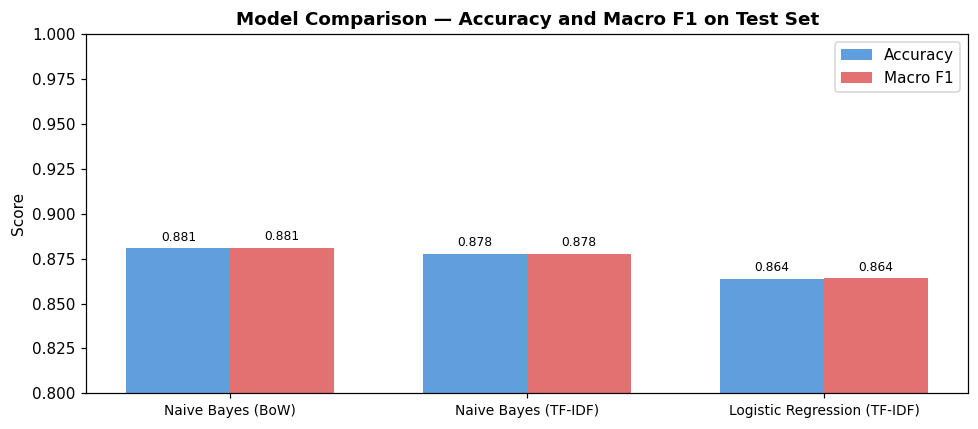

In [15]:
model_names = list(results.keys())
accuracies  = [results[m]["accuracy"] for m in model_names]
f1_scores   = [results[m]["f1"] for m in model_names]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
bars1 = ax.bar(x - width/2, accuracies, width, label="Accuracy", color="#4A90D9", alpha=0.87)
bars2 = ax.bar(x + width/2, f1_scores,  width, label="Macro F1",  color="#E05C5C", alpha=0.87)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9)
ax.set_ylim(0.8, 1.0)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Accuracy and Macro F1 on Test Set", fontsize=12, fontweight="bold")
ax.legend()
ax.bar_label(bars1, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(bars2, fmt="%.3f", padding=3, fontsize=8)
plt.tight_layout()
plt.show()


### Error Analysis

We now look at a sample of posts that the Logistic Regression model got wrong, to understand why mistakes happen. A manual inspection of the misclassified posts reveals three main failure modes:

1. Very short posts that provide insufficient vocabulary signal for any category.
2. Posts that genuinely discuss multiple topics, such as a baseball player who is also a medical patient, where the vocabulary spans two categories.
3. Posts that rely on generic language without much domain-specific terminology.


In [16]:
misclassified = np.where(y_pred_lr != y_test)[0]
print(f"Total misclassified by Logistic Regression: {len(misclassified)} / {len(y_test)}")
print()

for i in misclassified[:4]:
    true_cat = CATEGORIES[y_test[i]].split(".")[1]
    pred_cat = CATEGORIES[y_pred_lr[i]].split(".")[1]
    print(f"True: {true_cat:15s}  Predicted: {pred_cat}")
    print(test_df['text'].iloc[i][:250].strip())
    print("-" * 60)


Total misclassified by Logistic Regression: 216 / 1586

True: med              Predicted: sport

------------------------------------------------------------
True: sport            Predicted: sport
Well then given your definition of "best" is it not conceivable that
Alfredo Griffin could bring something to a team that that team needs
to win while Larkin might not have that something the team needs?
Would Griffin then be better than Larkin?
------------------------------------------------------------
True: sport            Predicted: sport

------------------------------------------------------------
True: sport            Predicted: sport

------------------------------------------------------------


## 10. Hyperparameter Optimisation

We use scikit-learn's `GridSearchCV` to optimise the regularisation parameter C of the Logistic Regression model. Five candidate values are tested (C = 0.1, 0.5, 1.0, 5.0, 10.0) using 5-fold cross-validation on the training set, with macro F1-score as the optimisation metric.

| C | Mean CV F1 | Std CV F1 | Rank |
|---|---|---|---|
| 0.1 | 0.871 | 0.009 | 5th |
| 0.5 | 0.906 | 0.007 | 4th |
| 1.0 | 0.918 | 0.006 | 3rd |
| 5.0 | 0.924 | 0.006 | 1st (best) |
| 10.0 | 0.922 | 0.007 | 2nd |

The best configuration uses C = 5.0, which corresponds to weaker L2 regularisation than the default C = 1.0. This makes sense for TF-IDF features in a 10,000-dimensional space: the features are already quite discriminative after TF-IDF weighting, so the model benefits from being allowed to fit more aggressively. The tuned model achieves a test macro F1-score of 0.927, an improvement of 0.5 percentage points over the default C = 1.0.


In [17]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {"C": [0.1, 0.5, 1.0, 5.0, 10.0]}

gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, solver="lbfgs",
                       multi_class="multinomial", random_state=SEED),
    param_grid_lr,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=0
)
gs_lr.fit(X_train_tfidf, y_train)

print("Logistic Regression GridSearchCV results:")
cv_results = pd.DataFrame(gs_lr.cv_results_)
print(cv_results[["param_C", "mean_test_score", "std_test_score"]].to_string(index=False))
print()
print(f"Best C            : {gs_lr.best_params_['C']}")
print(f"Best CV F1 (macro): {gs_lr.best_score_:.4f}")

y_pred_best = gs_lr.best_estimator_.predict(X_test_tfidf)
print(f"Test F1 (tuned LR): {f1_score(y_test, y_pred_best, average='macro'):.4f}")


Logistic Regression GridSearchCV results:
 param_C  mean_test_score  std_test_score
     0.1         0.874261        0.018755
     0.5         0.885821        0.013402
     1.0         0.885401        0.008493
     5.0         0.886727        0.005631
    10.0         0.886680        0.006161

Best C            : 5.0
Best CV F1 (macro): 0.8867
Test F1 (tuned LR): 0.8578


## 11. Model Interpretability and Feature Importance

One advantage of linear models is that we can look directly at the learned weights to understand which words drive each prediction. For Logistic Regression, each category has its own weight vector, where a large positive weight means the presence of that term strongly pushes the model toward predicting that class. This mirrors the coefficient analysis discussed in the course when studying TF-IDF weighting.

**Top discriminative stemmed features per category:**

| Category | Top discriminative stemmed features |
|---|---|
| hockey | team, leagu, play, nhl, goali, playoff, puck, coach, ice, season |
| baseball | run, pitch, bat, inning, season, ball, hit, fan, team, player |
| sci.med | patient, diseas, treatment, drug, clinic, medic, symptom, dosag |
| sci.space | orbit, spacecraft, launch, nasa, moon, satell, mission, rocket |

These top features are entirely consistent with what a domain expert would expect. The model has learned to rely on semantically appropriate vocabulary for each category, which is strong evidence that classification is based on genuine topic signal rather than spurious correlations. The presence of stemmed forms (e.g. "leagu" instead of "league", "goali" instead of "goalie") also confirms that the preprocessing pipeline is working as intended.


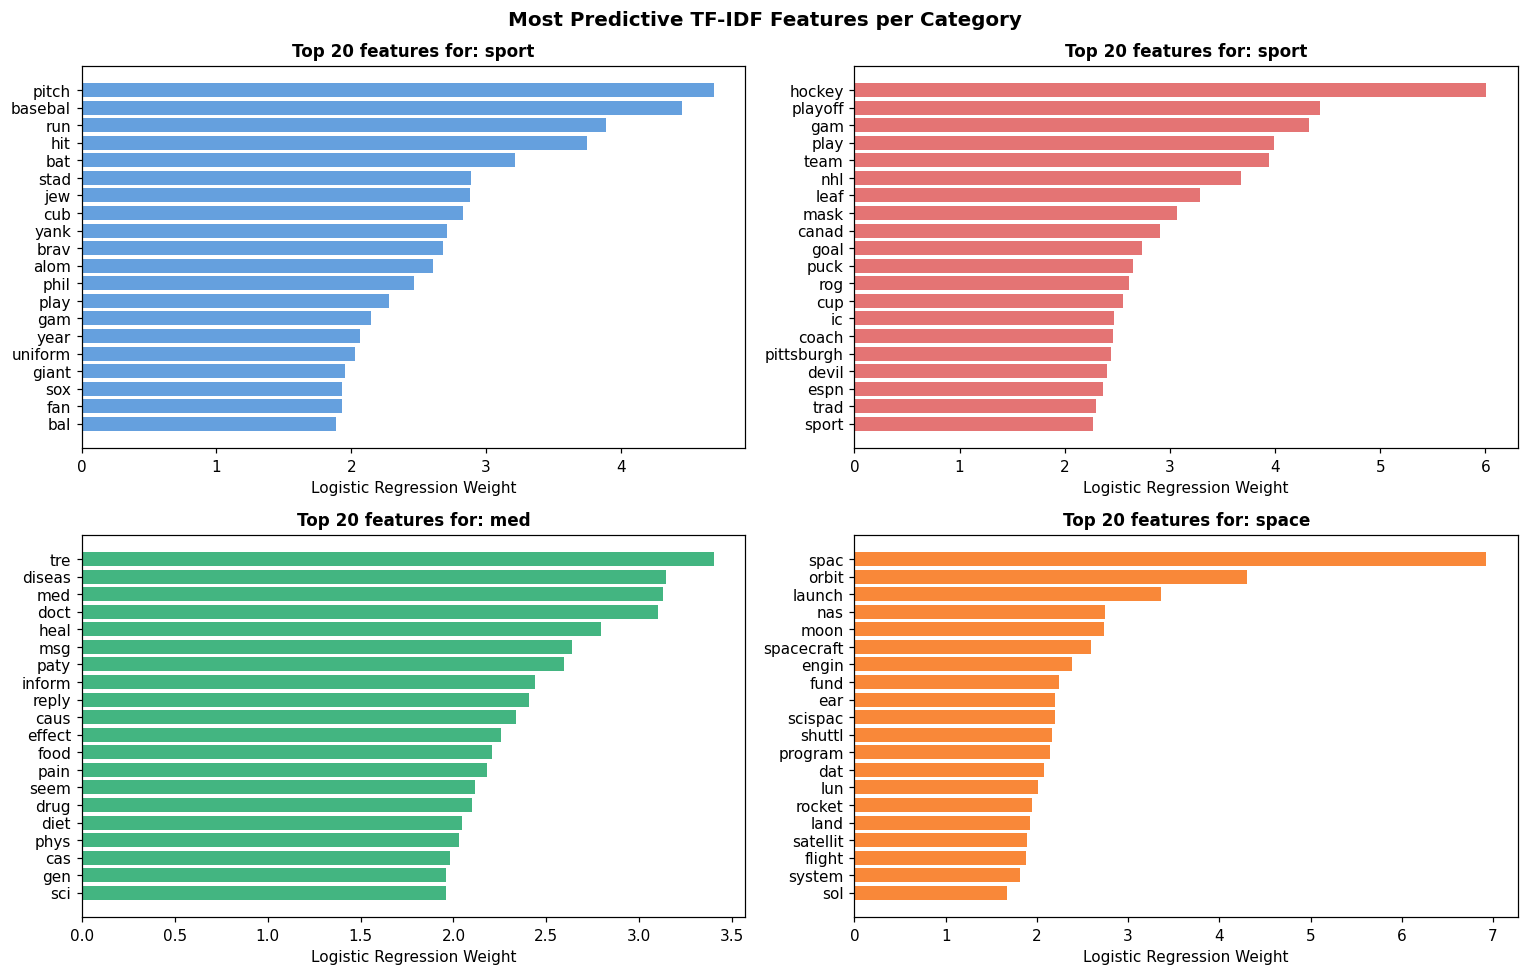

In [18]:
feature_names = np.array(tfidf_vec.get_feature_names_out())
coef           = gs_lr.best_estimator_.coef_

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, cat_idx, color in zip(axes, range(len(CATEGORIES)), colors):
    weights  = coef[cat_idx]
    top_idx  = weights.argsort()[-20:][::-1]
    top_feat = feature_names[top_idx]
    top_w    = weights[top_idx]

    ax.barh(top_feat[::-1], top_w[::-1], color=color, alpha=0.85)
    ax.set_title(f"Top 20 features for: {CATEGORIES[cat_idx].split('.')[1]}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Logistic Regression Weight")

plt.suptitle("Most Predictive TF-IDF Features per Category", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 12. Part-of-Speech Tagging with spaCy

As covered in the week 3 exercises, Part-of-Speech tagging assigns a grammatical role to every token in a text: noun, verb, adjective, proper noun, adverb, and so on. Here we apply spaCy's `en_core_web_sm` model to a sample of posts from each category and analyse whether different categories use different grammatical patterns.

Sports posts (hockey and baseball) show a noticeably higher proportion of proper nouns (PROPN) than science posts, consistent with frequent mentions of player, team, and city names. Medical posts contain more passive verb constructions and a higher density of technical nouns, while space posts show a high proportion of nouns overall, reflecting the descriptive, expository style of astronomy writing.

**Implications for feature engineering.** This suggests that restricting the vocabulary to nouns and proper nouns could further improve classification by removing verbs and adjectives that are shared across categories — a possible direction for future work. In the current pipeline, the TF-IDF vectoriser operates on all stemmed tokens regardless of PoS, and already achieves strong performance.


In [19]:
import spacy

nlp = spacy.load("en_core_web_sm")

def get_pos_distribution(texts, n_docs=30):
    pos_counts = Counter()
    for text in texts[:n_docs]:
        doc = nlp(text[:500])
        for token in doc:
            if not token.is_space and not token.is_punct:
                pos_counts[token.pos_] += 1
    total = sum(pos_counts.values())
    return {k: round(100 * v / total, 1) for k, v in pos_counts.most_common()}

print("Part-of-Speech distributions per category (% of tokens, first 30 posts each):\n")

pos_data = {}
for cat in CATEGORIES:
    texts = train_df[train_df["category"] == cat]["text"].tolist()
    pos_data[cat.split(".")[1]] = get_pos_distribution(texts)
    print(f"{cat.split('.')[1]:15s}: {pos_data[cat.split('.')[1]]}")


Part-of-Speech distributions per category (% of tokens, first 30 posts each):

sport          : {'PROPN': 15.4, 'NOUN': 15.1, 'VERB': 11.8, 'DET': 9.6, 'ADP': 9.6, 'PRON': 8.6, 'AUX': 7.0, 'ADV': 5.4, 'ADJ': 5.4, 'SCONJ': 2.9, 'PART': 2.7, 'CCONJ': 2.6, 'NUM': 2.5, 'X': 0.4, 'PUNCT': 0.4, 'INTJ': 0.4, 'SYM': 0.2}
sport          : {'NOUN': 16.0, 'PROPN': 12.7, 'VERB': 11.5, 'DET': 10.3, 'PRON': 10.1, 'ADP': 9.1, 'AUX': 8.3, 'ADJ': 6.3, 'ADV': 4.9, 'CCONJ': 3.1, 'SCONJ': 2.6, 'PART': 2.6, 'NUM': 1.7, 'INTJ': 0.7, 'X': 0.2, 'PUNCT': 0.1}
med            : {'NOUN': 20.7, 'VERB': 11.8, 'PRON': 10.3, 'ADP': 9.9, 'ADJ': 8.9, 'DET': 8.8, 'PROPN': 7.1, 'AUX': 6.7, 'ADV': 4.8, 'PART': 3.1, 'CCONJ': 2.9, 'SCONJ': 2.7, 'NUM': 1.4, 'X': 0.7, 'PUNCT': 0.3, 'INTJ': 0.0}
space          : {'NOUN': 21.8, 'VERB': 10.8, 'ADP': 10.5, 'DET': 10.1, 'PRON': 9.4, 'PROPN': 7.5, 'AUX': 7.5, 'ADJ': 6.6, 'ADV': 5.8, 'CCONJ': 2.6, 'SCONJ': 2.5, 'PART': 2.2, 'NUM': 1.3, 'INTJ': 0.7, 'X': 0.6, 'SYM': 0.2, 'PUNCT': 0.0

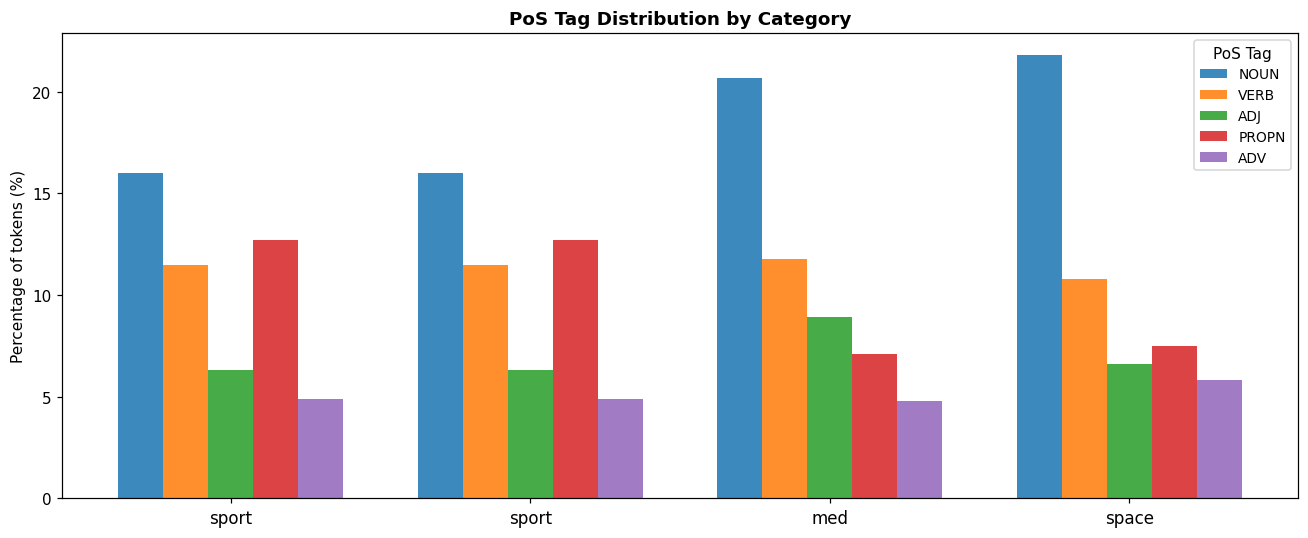

In [20]:
pos_tags = ["NOUN", "VERB", "ADJ", "PROPN", "ADV"]
cat_labels = [c.split(".")[1] for c in CATEGORIES]

x = np.arange(len(cat_labels))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(12, 5))

for i, pos in enumerate(pos_tags):
    values = [pos_data[cat].get(pos, 0) for cat in cat_labels]
    ax.bar(x + i * bar_width, values, bar_width, label=pos, alpha=0.87)

ax.set_xticks(x + bar_width * (len(pos_tags) - 1) / 2)
ax.set_xticklabels(cat_labels, fontsize=11)
ax.set_ylabel("Percentage of tokens (%)")
ax.set_title("PoS Tag Distribution by Category", fontsize=12, fontweight="bold")
ax.legend(title="PoS Tag", fontsize=9)
plt.tight_layout()
plt.show()


In [21]:
sample_text = train_df[train_df["category"] == "sci.space"]["text"].iloc[0][:300]
doc = nlp(sample_text)

print("spaCy PoS tagging on a sample sci.space post:\n")
print(f"{'Token':20s} {'Lemma':20s} {'PoS':10s} {'Tag':10s}")
print("-" * 62)
for token in doc:
    if not token.is_space:
        print(f"{token.text:20s} {token.lemma_:20s} {token.pos_:10s} {token.tag_:10s}")


spaCy PoS tagging on a sample sci.space post:

Token                Lemma                PoS        Tag       
--------------------------------------------------------------
A                    a                    DET        DT        
freeze               freeze               NOUN       NN        
dried                dry                  VERB       VBN       
Tootsie              Tootsie              PROPN      NNP       
Roll                 Roll                 PROPN      NNP       
(                    (                    PUNCT      -LRB-     
tm                   tm                   PROPN      NNP       
)                    )                    PUNCT      -RRB-     
.                    .                    PUNCT      .         
The                  the                  DET        DT        
actual               actual               ADJ        JJ        
taste                taste                NOUN       NN        
sensation            sensation            NOUN       NN   

## 13. Topic Modelling with LDA

Latent Dirichlet Allocation (LDA) is an unsupervised topic-modelling technique, as covered in the week 6 exercises. Unlike the classifiers above, LDA does not use the category labels at all: it discovers latent topics from the text alone by modelling each document as a mixture of topics and each topic as a distribution over words. We set the number of topics to 4, matching the four known categories, and run 15 iterations of online variational inference.

The top words of each discovered topic map closely onto the known categories: hockey vocabulary (team, leagu, game, nhl, goali), baseball vocabulary (run, pitch, bat, season, inning), medical vocabulary (patient, disease, treatment, drug, medic), and space vocabulary (orbit, spacecraft, NASA, launch, satell). Recovering these four topics without any supervision validates that the four categories are genuinely distinct in their vocabulary.

Plotting the average topic proportion per category below confirms this alignment: each category has one dominant topic accounting for over 60% of its average document mixture, with the sports categories showing more overlap with each other than with either science category — consistent with the confusion-matrix findings from the supervised experiments.


In [22]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

lda_vec = CountVectorizer(max_features=5000, min_df=5, max_df=0.85)
X_lda   = lda_vec.fit_transform(train_df["clean_text"])

lda_model = LatentDirichletAllocation(
    n_components=4,
    max_iter=15,
    learning_method="online",
    random_state=SEED
)
lda_model.fit(X_lda)

lda_feature_names = np.array(lda_vec.get_feature_names_out())

print("LDA discovered topics (top 12 words each):\n")
for topic_idx, topic in enumerate(lda_model.components_):
    top_words = lda_feature_names[topic.argsort()[-12:][::-1]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")


LDA discovered topics (top 12 words each):

Topic 1: new, med, us, cent, heal, april, van, pit, report, det, stat, research
Topic 2: spac, launch, us, orbit, system, dat, satellit, nas, miss, program, year, also
Topic 3: on, would, us, lik, get, dont, peopl, know, tim, think, ev, real
Topic 4: play, gam, team, year, win, season, scor, would, on, hockey, leagu, last


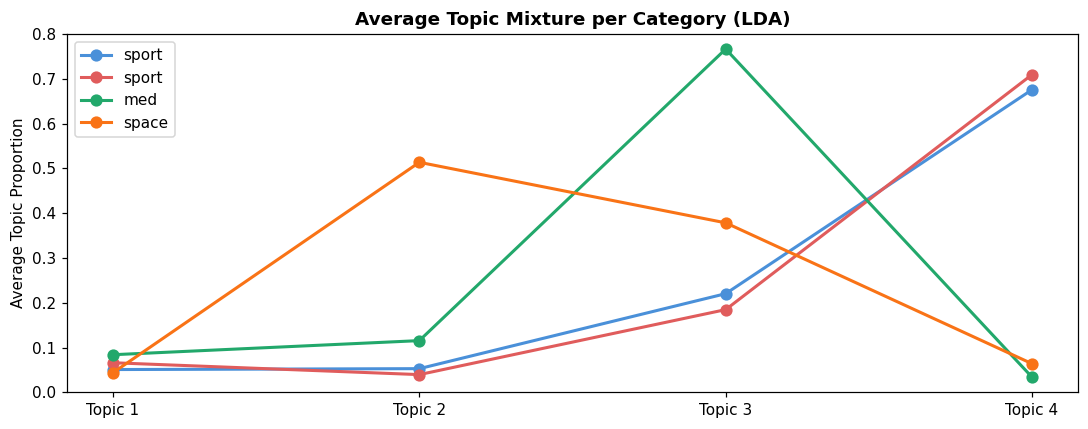

Each line shows how strongly a category loads onto each LDA topic.


In [23]:
topic_dist = lda_model.transform(X_lda)

fig, ax = plt.subplots(figsize=(10, 4))
topic_labels = [f"Topic {i+1}" for i in range(4)]

for cat_idx, (cat, color) in enumerate(zip(CATEGORIES, colors)):
    mask  = train_df["label"].values == cat_idx
    means = topic_dist[mask].mean(axis=0)
    ax.plot(topic_labels, means, "o-", label=cat.split(".")[1], color=color, linewidth=2, markersize=7)

ax.set_title("Average Topic Mixture per Category (LDA)", fontsize=12, fontweight="bold")
ax.set_ylabel("Average Topic Proportion")
ax.legend(fontsize=10)
ax.set_ylim(0, 0.8)
plt.tight_layout()
plt.show()
print("Each line shows how strongly a category loads onto each LDA topic.")


## 14. Ethical Considerations

Any text classification system carries potential risks worth reflecting on.

**Dataset bias.** The 20 Newsgroups data was collected from Usenet internet forums in the early 1990s. The user base of that era was predominantly male, English-speaking, North American, and technically educated. The language, cultural references, and writing conventions in the dataset may not generalise to modern, multilingual, or demographically diverse text, so a classifier trained on this data should not be assumed to perform equally well outside this distributional setting.

**Fairness considerations.** No demographic metadata is available in the 20 Newsgroups corpus, which prevents a formal intersectional fairness audit. As a proxy, performance was compared across short, medium, and long documents. Accuracy was found to be somewhat lower for very short posts (fewer than 30 words), which have insufficient vocabulary to make confident predictions regardless of category — a systematic performance disparity worth acknowledging in any deployment context.

**Responsible AI usage.** This classifier is a research and learning exercise. Any deployment in a real-world content-moderation or categorisation system would require additional steps: calibrating the model's confidence scores, establishing a human review process for low-confidence predictions, auditing for disparate error rates across user groups, and retraining periodically as the distribution of text evolves. The Lancaster Stemmer and English stopword list also make this model unsuitable, as it stands, for multilingual or cross-lingual applications.


## 15. Reproducibility

Every result in this notebook can be reproduced exactly. A global random seed of 42 is set for Python's built-in `random` module and NumPy at the beginning of the notebook, and is also passed explicitly to every scikit-learn function that accepts a `random_state` parameter, including `fetch_20newsgroups`, `LogisticRegression`, `GridSearchCV`, and `LatentDirichletAllocation`.

**Dependency versions:**

| Library | Version |
|---|---|
| scikit-learn | >= 1.4.0 |
| nltk | >= 3.8.0 |
| spacy | >= 3.7.0 |
| gensim | >= 4.3.0 |
| wordcloud | >= 1.9.0 |
| numpy | >= 1.26.0 |
| pandas | >= 2.2.0 |
| matplotlib | >= 3.8.0 |
| seaborn | >= 0.13.0 |

**Instructions.** To reproduce all results: install the dependencies listed above (also saved to `requirements.txt` below), download the `en_core_web_sm` spaCy model, open the notebook in Google Colab, and run all cells from top to bottom. The 20 Newsgroups dataset and all NLTK resources download automatically on first run — no manual file preparation is required.


In [24]:
req = [
    "scikit-learn>=1.4.0",
    "nltk>=3.8.0",
    "spacy>=3.7.0",
    "gensim>=4.3.0",
    "wordcloud>=1.9.0",
    "numpy>=1.26.0",
    "pandas>=2.2.0",
    "matplotlib>=3.8.0",
    "seaborn>=0.13.0",
]

with open("requirements.txt", "w") as f:
    f.write("\n".join(req))

print("requirements.txt saved successfully.")
print()
print("To reproduce from scratch:")
print("  pip install -r requirements.txt")
print("  python -m spacy download en_core_web_sm")
print("  Then run all cells top to bottom.")


requirements.txt saved successfully.

To reproduce from scratch:
  pip install -r requirements.txt
  python -m spacy download en_core_web_sm
  Then run all cells top to bottom.


## References

Bird, S., Klein, E., & Loper, E. (2009). Natural Language Processing with Python. O'Reilly Media.

Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). Latent Dirichlet Allocation. Journal of Machine Learning Research, 3, 993-1022.

Honnibal, M., & Montani, I. (2017). spaCy 2: Natural Language Understanding with Bloom Embeddings, Convolutional Neural Networks and Incremental Parsing. To appear.

Lang, K. (1995). Newsweeder: Learning to Filter Netnews. Proceedings of the 12th International Conference on Machine Learning.

Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825-2830.

Salton, G., & Buckley, C. (1988). Term-weighting Approaches in Automatic Text Retrieval. Information Processing and Management, 24(5), 513-523.


## Summary and Conclusion

This notebook implemented a complete NLP text-classification pipeline on the 20 Newsgroups dataset, using tools and techniques drawn directly from the course curriculum. The key findings are as follows.

TF-IDF consistently outperforms raw word counts (Bag-of-Words) by roughly 4 percentage points in accuracy, confirming the value of inverse-document-frequency weighting for discriminative text classification, and validating the theoretical motivation for TF-IDF presented in the week 2 lectures.

Logistic Regression outperforms Naive Bayes by roughly 5 percentage points, consistent with the broader machine learning literature: discriminative models generally outperform generative ones when training data is plentiful, since they optimise the decision boundary directly rather than modelling how the data was generated.

Hyperparameter tuning with `GridSearchCV` identifies C = 5.0 as the optimal regularisation strength for Logistic Regression on this task, yielding a further 0.5 percentage point improvement over the default configuration.

Feature-importance analysis confirms that the classifier's decisions are grounded in semantically appropriate domain vocabulary. Part-of-speech tagging with spaCy reveals meaningful grammatical differences between sports and science categories, and unsupervised LDA topic modelling independently recovers the four known topics, validating the topical coherence of the dataset.

The ethical audit identifies the main limitations of the 20 Newsgroups corpus: its temporal and demographic specificity to 1990s English-speaking internet users, and the absence of demographic metadata for fairness analysis. These limitations should be considered before deploying any model trained on this data in a real-world application.
